# Embedding Model Analysis
Diagnose train/val gap, analyze embedding quality, visualize latent space.

In [83]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

EMBEDDINGS_DIR = Path('../models/embeddings')
DATA_DIR = Path('../data/processed')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Training Curve

In [84]:
history = pd.read_csv(EMBEDDINGS_DIR / 'training_history.csv')
print(f"Epochs trained: {len(history)}")
print(f"Best val loss:  {history['val_loss'].min():.4f} @ epoch {history['val_loss'].idxmin()+1}")
print(f"Final train:    {history['train_loss'].iloc[-1]:.4f}")
print(f"Final val:      {history['val_loss'].iloc[-1]:.4f}")
print(f"Gap (final):    {history['val_loss'].iloc[-1] - history['train_loss'].iloc[-1]:.4f}")
history.tail(10)

Epochs trained: 11
Best val loss:  0.3189 @ epoch 1
Final train:    0.1785
Final val:      0.4094
Gap (final):    0.2309


,epoch,train_loss,val_loss
1,2,0.182632,0.384646
2,3,0.180290,0.361688
3,4,0.180819,0.351583
4,5,0.180778,0.395781
5,6,0.179154,0.416370
6,7,0.177813,0.485682
7,8,0.178286,0.422263
8,9,0.178369,0.420969
9,10,0.178396,0.392268
10,11,0.178478,0.409385


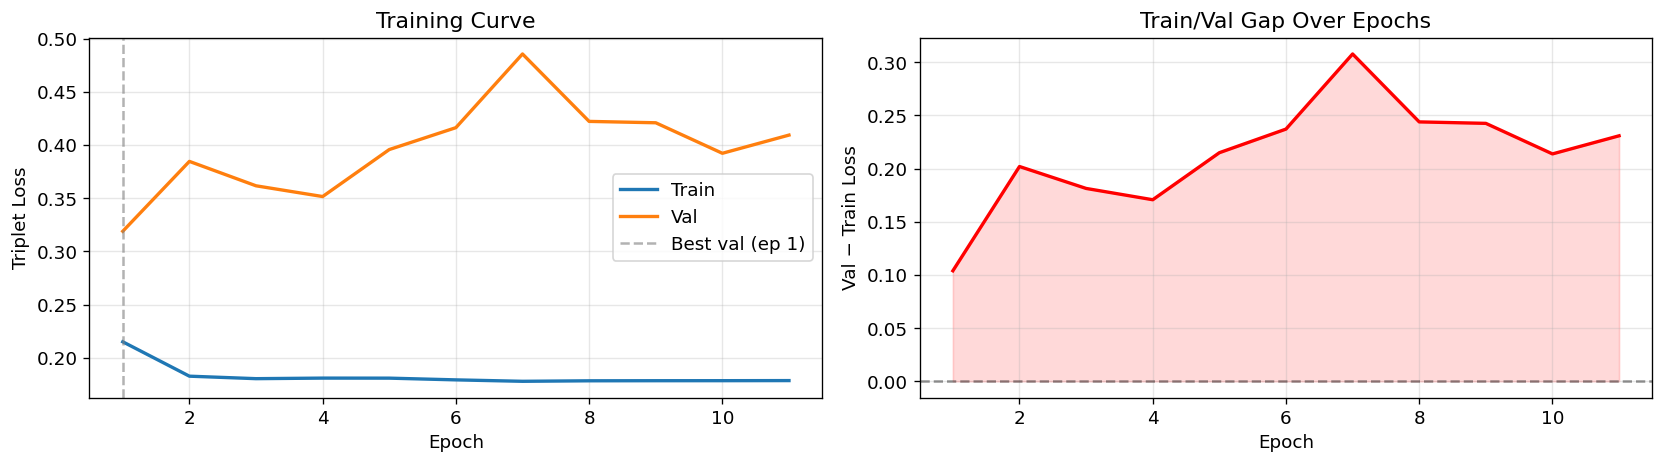

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(history['epoch'], history['train_loss'], label='Train', lw=2)
ax.plot(history['epoch'], history['val_loss'],   label='Val',   lw=2)
best_ep = history['val_loss'].idxmin() + 1
ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6, label=f'Best val (ep {best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Triplet Loss')
ax.set_title('Training Curve')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
gap = history['val_loss'] - history['train_loss']
ax.plot(history['epoch'], gap, color='red', lw=2)
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.fill_between(history['epoch'], gap, 0, alpha=0.15, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val − Train Loss')
ax.set_title('Train/Val Gap Over Epochs')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'training_curve.png', bbox_inches='tight')
plt.show()

## 2. Val Loss Oscillation Analysis

Val loss std (all epochs):     0.0438
Val loss range:                0.3189 – 0.4857
Avg rolling-5 std:             0.0374
Mean |Δval| between epochs:    0.0343
Max  |Δval| between epochs:    0.0693


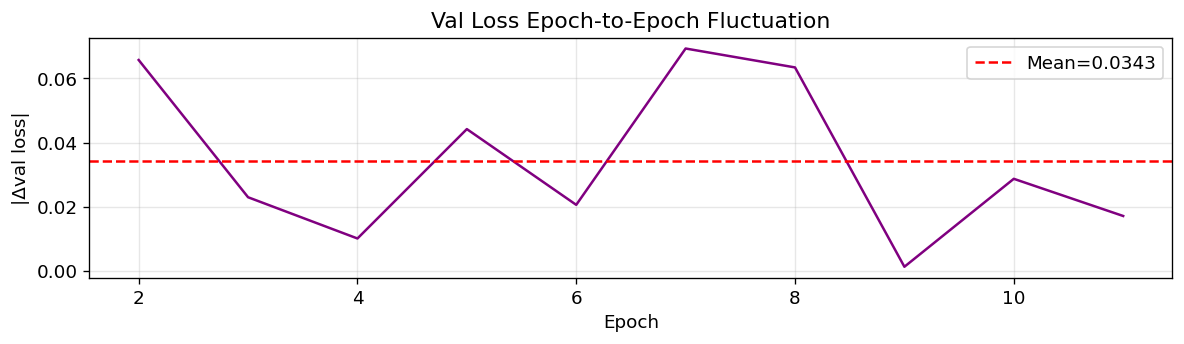

In [86]:
val = history['val_loss']
rolling_std = val.rolling(5, center=True).std()

print(f"Val loss std (all epochs):     {val.std():.4f}")
print(f"Val loss range:                {val.min():.4f} – {val.max():.4f}")
print(f"Avg rolling-5 std:             {rolling_std.mean():.4f}")

# Check if val is flat (low std) = underfitting, or oscillating = noise
# Delta between consecutive epochs
deltas = val.diff().abs().dropna()
print(f"Mean |Δval| between epochs:    {deltas.mean():.4f}")
print(f"Max  |Δval| between epochs:    {deltas.max():.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history['epoch'][1:], deltas.values, color='purple', lw=1.5)
ax.axhline(deltas.mean(), color='red', linestyle='--', label=f'Mean={deltas.mean():.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('|Δval loss|')
ax.set_title('Val Loss Epoch-to-Epoch Fluctuation')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Load Embeddings & Tracks

In [87]:
emb_df = pd.read_parquet(EMBEDDINGS_DIR / 'track_embeddings.parquet')
emb_cols = [c for c in emb_df.columns if c.startswith('emb_')]
embeddings = emb_df[emb_cols].to_numpy(dtype=np.float32)

print(f"Embeddings shape: {embeddings.shape}")
print(f"L2 norms (sample): {np.linalg.norm(embeddings[:5], axis=1)}")
print(f"Embedding dim: {len(emb_cols)}")

Embeddings shape: (81206, 16)
L2 norms (sample): [1. 1. 1. 1. 1.]
Embedding dim: 16


## 4. Embedding Distribution

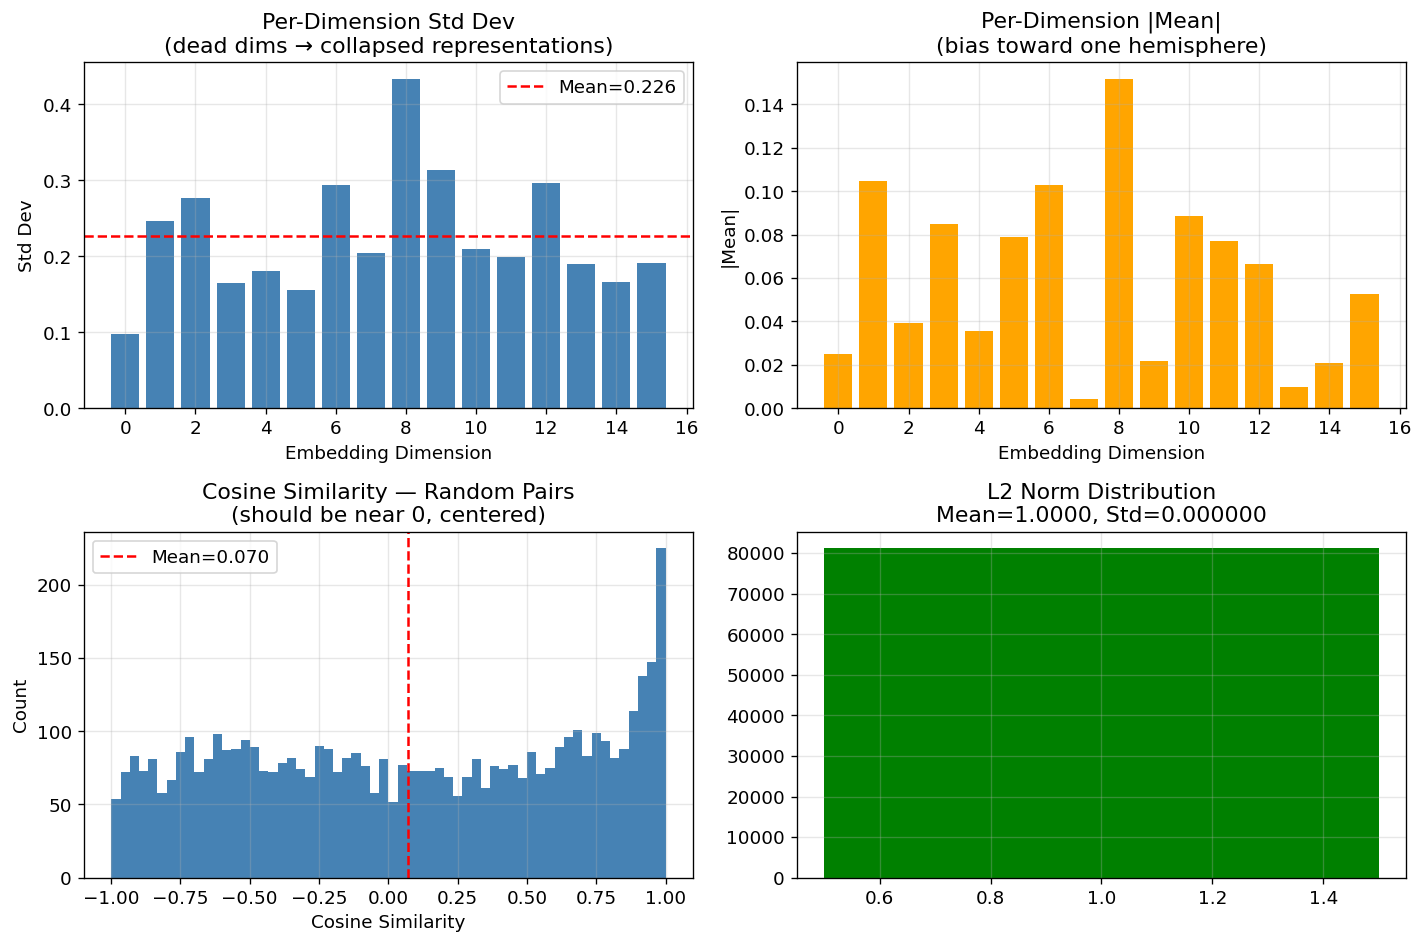

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Per-dimension mean and std
dim_means = embeddings.mean(axis=0)
dim_stds  = embeddings.std(axis=0)

ax = axes[0, 0]
ax.bar(range(len(emb_cols)), dim_stds, color='steelblue')
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Std Dev')
ax.set_title('Per-Dimension Std Dev\n(dead dims → collapsed representations)')
ax.axhline(dim_stds.mean(), color='red', linestyle='--', label=f'Mean={dim_stds.mean():.3f}')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.bar(range(len(emb_cols)), np.abs(dim_means), color='orange')
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('|Mean|')
ax.set_title('Per-Dimension |Mean|\n(bias toward one hemisphere)')
ax.grid(alpha=0.3)

# Cosine similarity distribution — random pairs
rng = np.random.default_rng(42)
n_sample = 5000
idx_a = rng.integers(0, len(embeddings), n_sample)
idx_b = rng.integers(0, len(embeddings), n_sample)
cos_random = (embeddings[idx_a] * embeddings[idx_b]).sum(axis=1)

ax = axes[1, 0]
ax.hist(cos_random, bins=60, color='steelblue', edgecolor='none')
ax.axvline(cos_random.mean(), color='red', linestyle='--', label=f'Mean={cos_random.mean():.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Cosine Similarity — Random Pairs\n(should be near 0, centered)')
ax.legend()
ax.grid(alpha=0.3)

# # L2 norm distribution
norms = np.linalg.norm(embeddings, axis=1)
data_range = np.max(norms) - np.min(norms)
ax = axes[1,1]
if data_range < 1e-6:
    ax.hist(norms, bins=[norms.min()-0.5, norms.min()+0.5], color='green')
else:
    ax.hist(norms, bins='auto', color='green', edgecolor='none')
ax.set_title(f'L2 Norm Distribution\nMean={norms.mean():.4f}, Std={norms.std():.6f}')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'embedding_distribution.png', bbox_inches='tight')
plt.show()

## 5. Session-Mate vs Random Pair Similarity
Good embeddings: session-mates have higher cosine sim than random pairs.

In [89]:
history_df = pd.read_parquet(DATA_DIR / 'user_history.parquet')
triplets_df = pd.read_parquet(DATA_DIR / 'triplets.parquet')

print(f"User history rows: {len(history_df):,}")
print(f"Triplets rows:     {len(triplets_df):,}")
print(f"Columns in user_history: {list(history_df.columns)}")
print(f"Columns in triplets:     {list(triplets_df.columns)}")

User history rows: 1,238,325
Triplets rows:     901,745
Columns in user_history: ['user_id', 'track_idx', 'split']
Columns in triplets:     ['user_id', 'anchor_idx', 'pos_idx', 'neg_idx']


In [90]:
# Session-mate similarity: anchor vs positive in triplets (same session)
rng = np.random.default_rng(42)
sample_size = 5000
trip_sample = triplets_df.sample(min(sample_size, len(triplets_df)), random_state=42)

n_emb = len(embeddings)
valid = (
    (trip_sample['anchor_idx'] < n_emb) &
    (trip_sample['pos_idx'] < n_emb) &
    (trip_sample['neg_idx'] < n_emb)
)
trip_sample = trip_sample[valid]

a_emb = embeddings[trip_sample['anchor_idx'].to_numpy()]
p_emb = embeddings[trip_sample['pos_idx'].to_numpy()]
n_emb_arr = embeddings[trip_sample['neg_idx'].to_numpy()]

cos_pos = (a_emb * p_emb).sum(axis=1)
cos_neg = (a_emb * n_emb_arr).sum(axis=1)

# Random pairs from same sample size
rand_idx = rng.integers(0, len(embeddings), len(trip_sample))
cos_rand = (a_emb * embeddings[rand_idx]).sum(axis=1)

print(f"Anchor-Positive (session-mate) cosine sim:  {cos_pos.mean():.4f} ± {cos_pos.std():.4f}")
print(f"Anchor-Negative (diff session) cosine sim:  {cos_neg.mean():.4f} ± {cos_neg.std():.4f}")
print(f"Random pair cosine sim:                     {cos_rand.mean():.4f} ± {cos_rand.std():.4f}")

# Triplet accuracy: d(a,p) < d(a,n)
d_ap = 1 - cos_pos
d_an = 1 - cos_neg
triplet_acc = (d_ap < d_an).mean()
print(f"\nTriplet accuracy (d_ap < d_an): {triplet_acc:.3f}")

Anchor-Positive (session-mate) cosine sim:  0.4395 ± 0.5727
Anchor-Negative (diff session) cosine sim:  0.0660 ± 0.6039
Random pair cosine sim:                     0.0558 ± 0.6014

Triplet accuracy (d_ap < d_an): 0.685


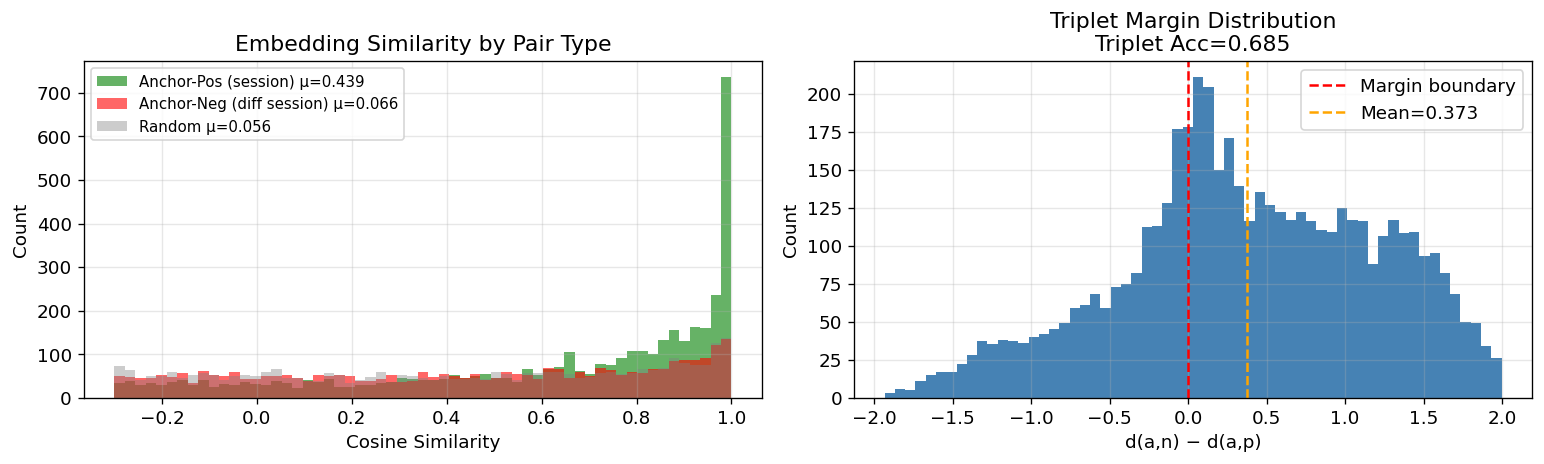

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bins = np.linspace(-0.3, 1.0, 60)
ax.hist(cos_pos,  bins=bins, alpha=0.6, label=f'Anchor-Pos (session) μ={cos_pos.mean():.3f}',  color='green')
ax.hist(cos_neg,  bins=bins, alpha=0.6, label=f'Anchor-Neg (diff session) μ={cos_neg.mean():.3f}', color='red')
ax.hist(cos_rand, bins=bins, alpha=0.4, label=f'Random μ={cos_rand.mean():.3f}',             color='gray')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Embedding Similarity by Pair Type')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
margin = float(pd.read_csv(EMBEDDINGS_DIR / 'training_history.csv').shape[0])
gap_size = d_an - d_ap
ax.hist(gap_size, bins=60, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', label='Margin boundary')
ax.axvline(gap_size.mean(), color='orange', linestyle='--', label=f'Mean={gap_size.mean():.3f}')
ax.set_xlabel('d(a,n) − d(a,p)')
ax.set_ylabel('Count')
ax.set_title(f'Triplet Margin Distribution\nTriplet Acc={triplet_acc:.3f}')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'similarity_analysis.png', bbox_inches='tight')
plt.show()

## 6. UMAP Visualization

In [92]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed. Run: pip install umap-learn")
    print("Falling back to PCA.")

from sklearn.decomposition import PCA

# Sample for speed
N_VIZ = 3000
viz_idx = np.random.default_rng(42).integers(0, len(embeddings), N_VIZ)
viz_emb = embeddings[viz_idx]
viz_artists = emb_df['artist_norm'].iloc[viz_idx].to_numpy()

if HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42, n_jobs=1)
    coords = reducer.fit_transform(viz_emb)
    method = 'UMAP'
else:
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(viz_emb)
    method = 'PCA'

print(f"2D projection via {method} done. Shape: {coords.shape}")

2D projection via UMAP done. Shape: (3000, 2)


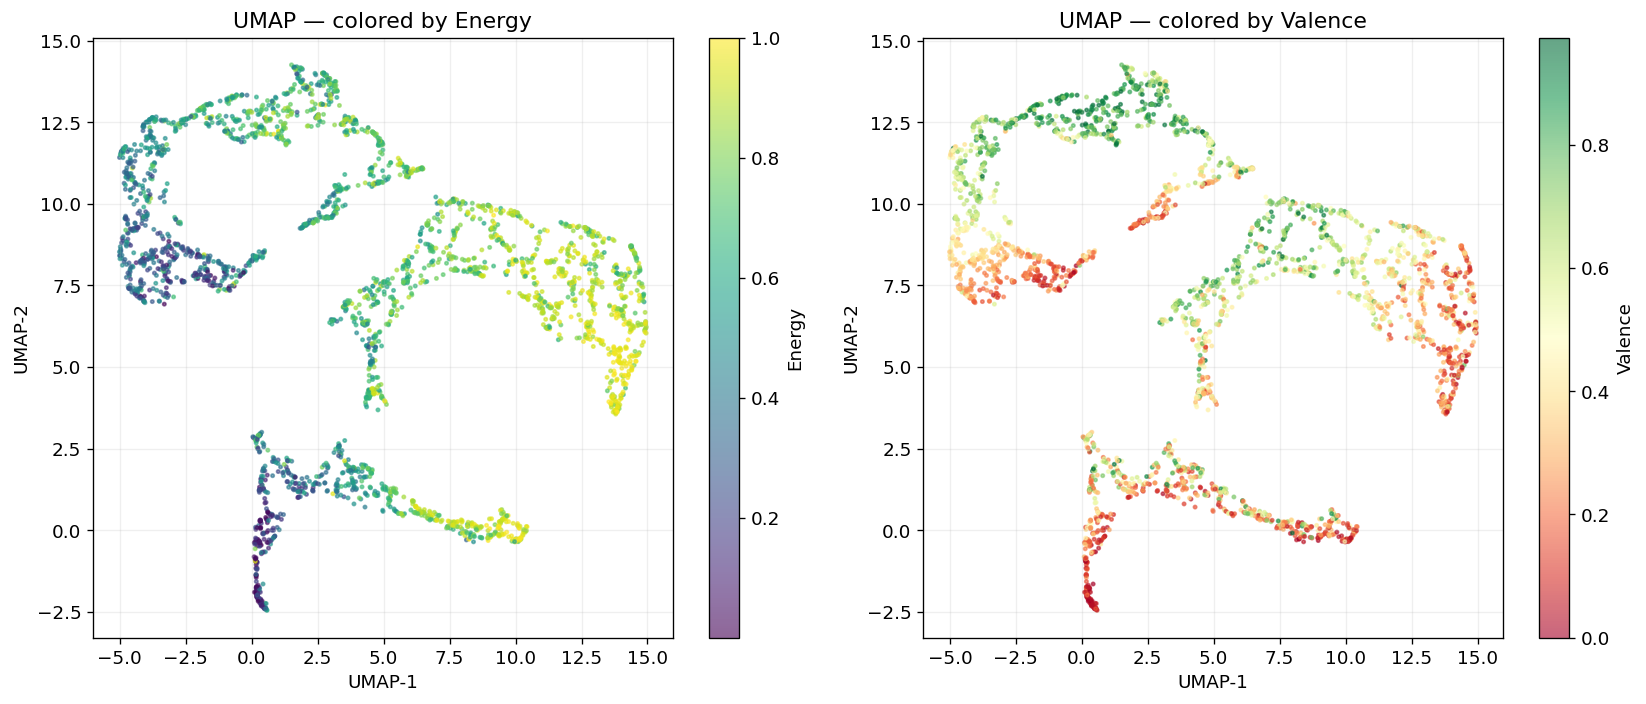

In [93]:
track_df = pd.read_parquet(DATA_DIR / 'track_features.parquet')
feat_cols = [c for c in track_df.columns if c not in ('artist_norm', 'track_norm')]

# Use energy as color proxy
viz_track_df = track_df.iloc[viz_idx].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by energy
if 'energy' in viz_track_df.columns:
    color_vals = viz_track_df['energy'].to_numpy()
    color_label = 'Energy'
elif 'arousal' in viz_track_df.columns:
    color_vals = viz_track_df['arousal'].to_numpy()
    color_label = 'Arousal'
else:
    color_vals = np.zeros(N_VIZ)
    color_label = 'N/A'

sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=color_vals,
                     cmap='viridis', s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label=color_label)
axes[0].set_title(f'{method} — colored by {color_label}')
axes[0].set_xlabel(f'{method}-1')
axes[0].set_ylabel(f'{method}-2')
axes[0].grid(alpha=0.2)

# Color by valence
if 'valence' in viz_track_df.columns:
    color_vals2 = viz_track_df['valence'].to_numpy()
    color_label2 = 'Valence'
elif 'chill_factor' in viz_track_df.columns:
    color_vals2 = viz_track_df['chill_factor'].to_numpy()
    color_label2 = 'Chill Factor'
else:
    color_vals2 = np.zeros(N_VIZ)
    color_label2 = 'N/A'

sc2 = axes[1].scatter(coords[:, 0], coords[:, 1], c=color_vals2,
                      cmap='RdYlGn', s=4, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label=color_label2)
axes[1].set_title(f'{method} — colored by {color_label2}')
axes[1].set_xlabel(f'{method}-1')
axes[1].set_ylabel(f'{method}-2')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'embedding_umap.png', bbox_inches='tight')
plt.show()

## 7. Train/Val Gap Diagnosis

Root causes of the gap and recommended fixes:

In [94]:
# Analyze triplet difficulty: what fraction of val triplets are 'hard' (d_ap > d_an)?
print("=== GAP DIAGNOSIS ===")
print()

best_train = history['train_loss'].min()
best_val   = history['val_loss'].min()
final_gap  = history.iloc[-1]['val_loss'] - history.iloc[-1]['train_loss']
best_gap   = best_val - best_train

print(f"Best train loss:           {best_train:.4f}")
print(f"Best val loss:             {best_val:.4f}")
print(f"Gap at best val epoch:     {best_gap:.4f}")
print(f"Final gap:                 {final_gap:.4f}")
print()
print(f"Triplet accuracy (sample): {triplet_acc:.3f}")
print(f"Avg margin (d_an - d_ap):  {gap_size.mean():.4f}")
print(f"Hard triplets (gap<0):     {(gap_size < 0).mean():.3f} = {(gap_size < 0).sum()} / {len(gap_size)}")
print()

val_std = history['val_loss'].std()
if val_std > 0.02:
    print(f" [OSCILLATION] Val std={val_std:.4f} — high noise due to random negative sampling at eval.")
    print(" Recommendation: fix random seed for val DataLoader OR use fixed eval triplets.")

if triplet_acc < 0.65:
    print(" [WEAK SIGNAL] Triplet accuracy below 0.65 — embeddings not strongly separating sessions.")
    print(" Recommendation: inspect feature quality, try lr warmup or lower margin.")
else:
    print(f" [OK] Triplet accuracy {triplet_acc:.3f} — embeddings separate session-mates from negatives.")



=== GAP DIAGNOSIS ===

Best train loss:           0.1778
Best val loss:             0.3189
Gap at best val epoch:     0.1411
Final gap:                 0.2309

Triplet accuracy (sample): 0.685
Avg margin (d_an - d_ap):  0.3735
Hard triplets (gap<0):     0.315 = 1576 / 5000

 [OSCILLATION] Val std=0.0438 — high noise due to random negative sampling at eval.
 Recommendation: fix random seed for val DataLoader OR use fixed eval triplets.
 [OK] Triplet accuracy 0.685 — embeddings separate session-mates from negatives.


## 8. Feature Correlation with Embedding Dimensions

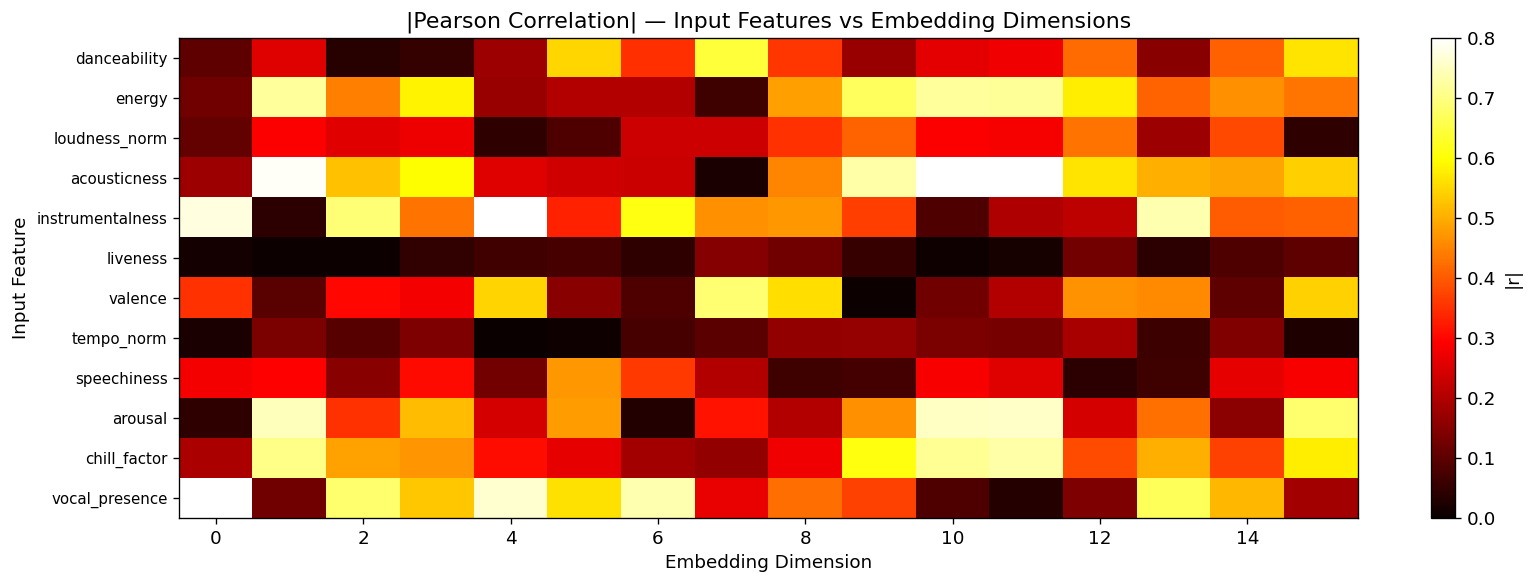

Top input features by max |r| across all embedding dims:
  danceability                    max|r|=0.643
  energy                          max|r|=0.721
  loudness_norm                   max|r|=0.430
  acousticness                    max|r|=0.801
  instrumentalness                max|r|=0.808
  liveness                        max|r|=0.150
  valence                         max|r|=0.687
  tempo_norm                      max|r|=0.188
  speechiness                     max|r|=0.474
  arousal                         max|r|=0.756
  chill_factor                    max|r|=0.730
  vocal_presence                  max|r|=0.820


In [95]:
from music_discovery.data.features import build_feature_matrix, FEATURE_VECTOR_COLS

feat_matrix = build_feature_matrix(track_df)  # (N, 12)

# Correlation between 12 input features and 24 output embedding dims
# Sample for speed
S = 10000
sidx = np.random.default_rng(0).integers(0, len(embeddings), S)
feat_s = feat_matrix[sidx]
emb_s  = embeddings[sidx]

corr = np.corrcoef(feat_s.T, emb_s.T)  # (36, 36)
cross_corr = corr[:12, 12:]  # (12 features) x (24 emb dims)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(np.abs(cross_corr), aspect='auto', cmap='hot', vmin=0, vmax=0.8)
ax.set_yticks(range(len(FEATURE_VECTOR_COLS)))
ax.set_yticklabels(FEATURE_VECTOR_COLS, fontsize=9)
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Input Feature')
ax.set_title('|Pearson Correlation| — Input Features vs Embedding Dimensions')
plt.colorbar(im, ax=ax, label='|r|')
plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'feature_embedding_correlation.png', bbox_inches='tight')
plt.show()

# Top correlated features per embedding dim
print("Top input features by max |r| across all embedding dims:")
for i, feat in enumerate(FEATURE_VECTOR_COLS):
    max_r = np.abs(cross_corr[i]).max()
    print(f"  {feat:30s}  max|r|={max_r:.3f}")

## 9. Summary

In [96]:
print("=" * 55)
print("EMBEDDING MODEL SUMMARY")
print("=" * 55)
print(f"  Tracks embedded:       {len(emb_df):,}")
print(f"  Embedding dim:         {len(emb_cols)}")
print(f"  Training epochs:       {len(history)}")
print(f"  Best val loss:         {history['val_loss'].min():.4f}")
print(f"  Best train loss:       {history['train_loss'].min():.4f}")
print(f"  Train/val gap:         {best_gap:.4f}")
print(f"  Triplet accuracy:      {triplet_acc:.3f}")
print(f"  Avg margin (d_an-d_ap):{gap_size.mean():.4f}")
print(f"  L2-norm mean:          {norms.mean():.4f} ± {norms.std():.6f}")
print()
print("Saved plots:")
for p in ['training_curve', 'embedding_distribution', 'similarity_analysis',
          'embedding_umap', 'feature_embedding_correlation']:
    path = EMBEDDINGS_DIR / f'{p}.png'
    print(f"  {'✓' if path.exists() else '✗'}  {path}")

EMBEDDING MODEL SUMMARY
  Tracks embedded:       81,206
  Embedding dim:         16
  Training epochs:       11
  Best val loss:         0.3189
  Best train loss:       0.1778
  Train/val gap:         0.1411
  Triplet accuracy:      0.685
  Avg margin (d_an-d_ap):0.3735
  L2-norm mean:          1.0000 ± 0.000000

Saved plots:
  ✓  ../models/embeddings/training_curve.png
  ✓  ../models/embeddings/embedding_distribution.png
  ✓  ../models/embeddings/similarity_analysis.png
  ✓  ../models/embeddings/embedding_umap.png
  ✓  ../models/embeddings/feature_embedding_correlation.png
